# Titanic Survival Analysis

**Objective:** To uncover which passenger characteristics are most clearly associated with survival on the Titanic.


## Importing libraries and cleaning up data


In [1]:
import sys
print("Python Path:", sys.executable)
print("Python Version:", sys.version)


Python Path: /Users/samhithkonidena/My Data Journey/Data Job Prep/Portfolio/Analysis/Titanic_Analysis/.venv/bin/python
Python Version: 3.14.0 (main, Oct 28 2025, 12:03:45) [Clang 20.1.4 ]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch
import seaborn as sns
from IPython.display import display
import openpyxl

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

dfo = pd.read_csv("../Raw_Data/Titanic-Dataset.csv")
dfo.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Shape:", dfo.shape)
display(dfo.info())
display(dfo.describe(include="all").T)
display(dfo.isna().sum().sort_values(ascending=False).to_frame("missing_values"))


Shape: (891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


,missing_values
Cabin,687
Age,177
Embarked,2
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
SibSp,0
Parch,0


### Data-quality decisions

- `Age` is filled with the median because age is used for grouped comparisons and the median is less sensitive to outliers.
- `Embarked` is filled with its mode because only two values are missing.
- `Cabin` is converted into a simple `Cabin_Known` flag rather than guessing individual cabin values.


In [4]:
dfo["Age"] = dfo["Age"].fillna(dfo["Age"].median())
dfo["Embarked"] = dfo["Embarked"].fillna(dfo["Embarked"].mode()[0])
dfo["Cabin_Known"] = dfo["Cabin"].notna().astype(int)

dfo["Age_Category"] = pd.cut(
    dfo["Age"],
    bins=[-np.inf, 12, 25, 60, np.inf],
    labels=["Child", "Youth", "Adult", "Senior"]
)
dfo["Ship_Class"] = dfo["Pclass"].map({1: "First Class", 2: "Second Class", 3: "Third Class"})
dfo["Survivor?"] = dfo["Survived"].map({0: "No", 1: "Yes"})

# Keep the original lower-case column convention for the SQL-ready dataframe.
dfo.columns = dfo.columns.str.lower().str.replace(" ", "_")
dfo.head()


,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,cabin_known,age_category,ship_class,survivor?
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,Youth,Third Class,No
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,Adult,First Class,Yes
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,Adult,Third Class,Yes
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,Adult,First Class,Yes
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,Adult,Third Class,No


## First look: who survived?

The overall survival rate is our baseline. Every subgroup comparison below should be read against it.


In [5]:
overall_survival = dfo["survived"].mean()
print(f"Overall survival rate: {overall_survival:.1%}")

survival_by_class = (
    dfo.groupby("ship_class", observed=False)["survived"]
       .agg(["count", "sum", "mean"])
       .rename(columns={
           "count": "total_passengers",
           "sum": "survivors",
           "mean": "survival_rate"
       })
)
survival_by_class["non_survivors"] = survival_by_class["total_passengers"] - survival_by_class["survivors"]
survival_by_class["survival_rate"] = (survival_by_class["survival_rate"]*100).round(2)

survival_by_sex = (
    dfo.groupby("sex", observed=False)["survived"]
       .agg(["count", "sum", "mean"])
       .rename(columns={
           "count": "total_passengers",
           "sum": "survivors",
           "mean": "survival_rate"
       })
)
survival_by_sex["non_survivors"] = survival_by_sex["total_passengers"] - survival_by_sex["survivors"]
survival_by_sex["survival_rate"] = (survival_by_sex["survival_rate"]*100).round(2)

display(survival_by_class)
display(survival_by_sex)


Overall survival rate: 38.4%


,total_passengers,survivors,survival_rate,non_survivors
ship_class,,,,
First Class,216,136,62.96,80
Second Class,184,87,47.28,97
Third Class,491,119,24.24,372


,total_passengers,survivors,survival_rate,non_survivors
sex,,,,
female,314,233,74.20,81
male,577,109,18.89,468


## Visualisation 1 — survival by passenger class

Passenger class is a proxy for access and socioeconomic position. This chart makes the class gradient visible.


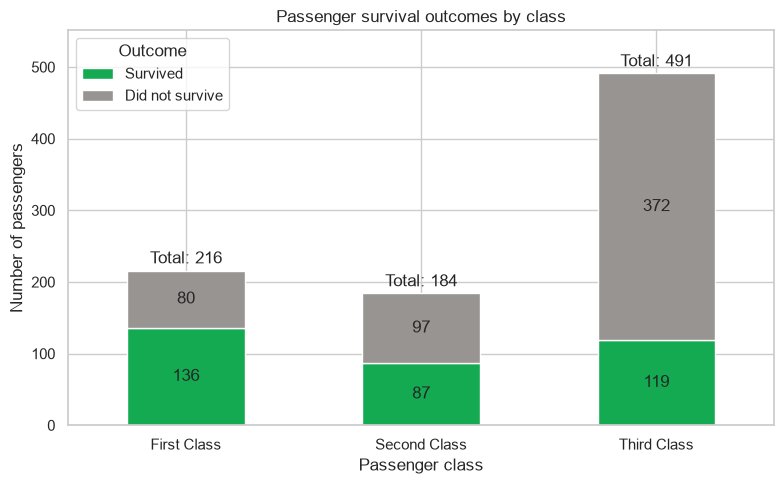

In [6]:
ax = survival_by_class[
    ["survivors", "non_survivors"]
].rename(columns={
    "survivors": "Survived",
    "non_survivors": "Did not survive"
}).plot(
    kind="bar",
    stacked=True,
    color=["#13aa52", "#989492"],
    figsize=(8, 5)
)

plt.title("Passenger survival outcomes by class")
plt.xlabel("Passenger class")
plt.ylabel("Number of passengers")
plt.xticks(rotation=0)
plt.legend(title="Outcome")
for container in ax.containers:
    ax.bar_label(container, label_type="center")
for i, total in enumerate(survival_by_class["total_passengers"]):
    ax.text(
        i,
        total + 10,
        f"Total: {total}",
        ha="center"
    )
ax.set_ylim(0, survival_by_class["total_passengers"].max() + 60)
plt.tight_layout()
plt.show()

## Visualisation 2 — survival by sex

Sex shows an even stronger difference in this dataset.


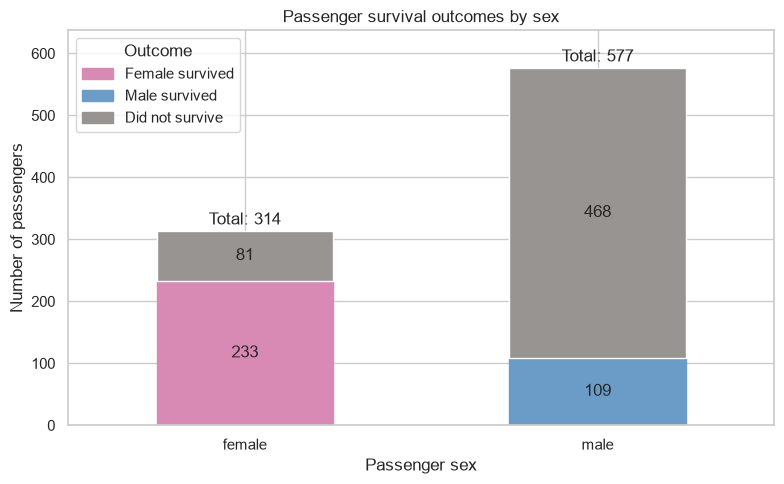

In [7]:
outcome_colors = ["#7da88f", "#e67e4a"]
ax = survival_by_sex[
    ["survivors", "non_survivors"]
].rename(columns={
    "survivors": "Survived",
    "non_survivors": "Did not survive"
}).plot(
    kind="bar",
    stacked=True,
    color=["#cccccc", "#989492"],
    figsize=(8, 5)
)

sex_survivor_colors = {
    "female": "#d88ab5",
    "male": "#6a9cc7"
}

for bar, sex in zip(ax.containers[0], survival_by_sex.index):
    bar.set_color(sex_survivor_colors[sex])

plt.title("Passenger survival outcomes by sex")
plt.xlabel("Passenger sex")
plt.ylabel("Number of passengers")
plt.xticks(rotation=0)
ax.legend(
    handles=[
        Patch(color="#d88ab5", label="Female survived"),
        Patch(color="#6a9cc7", label="Male survived"),
        Patch(color="#989492", label="Did not survive")
    ],
    title="Outcome"
)
for container in ax.containers:
    ax.bar_label(container, label_type="center")
for i, total in enumerate(survival_by_sex["total_passengers"]):
    ax.text(
        i,
        total + 10,
        f"Total: {total}",
        ha="center"
    )
ax.set_ylim(0, survival_by_sex["total_passengers"].max() + 60)
plt.tight_layout()
plt.show()


**On a lighter Note!:** *The above chart more or less hints that 'Jack' would've died regardless of other factors like age, passenger class, fare, solo travel, etc. Just the fact that he was a male journeyman on Titanic probably meant 'Rose' would've survived anyway!*

## Visualisation 3 — the interaction between sex and class

Looking at one variable at a time can hide important interactions. This heatmap shows how sex and class combine.


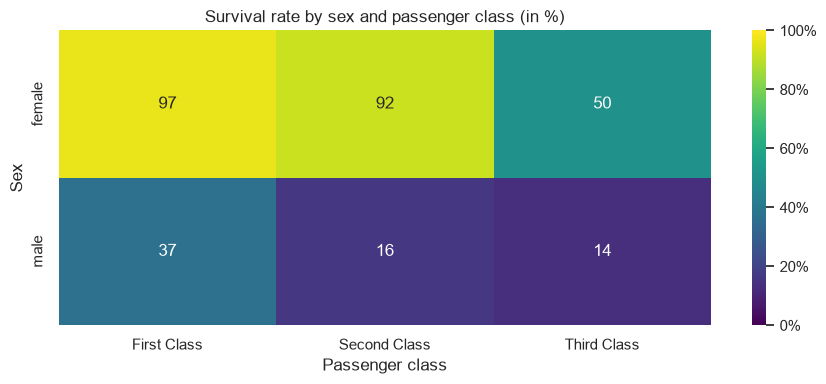

In [8]:
sex_class_survival = pd.pivot_table(dfo, values="survived", index="sex", columns="ship_class", aggfunc="mean", observed=False)
sex_class_survival_pct = sex_class_survival * 100
plt.figure(figsize=(9, 4))
ax = sns.heatmap(sex_class_survival_pct, annot=True, fmt=".0f", cmap="viridis", vmin=0, vmax=100)
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.title("Survival rate by sex and passenger class (in %)")
plt.xlabel("Passenger class")
plt.ylabel("Sex")
plt.tight_layout()
plt.show()


## Visualisation 4 — age groups

Age is continuous, so the derived `Age_Category` makes the comparison easier to communicate. Because missing ages were median-imputed, this chart should be interpreted as directional rather than a perfect age study.


,total_passengers,survivors,survival_rate,non_survivors
age_category,,,,
Child,69,40,57.97,29
Youth,232,84,36.21,148
Adult,568,213,37.50,355
Senior,22,5,22.73,17


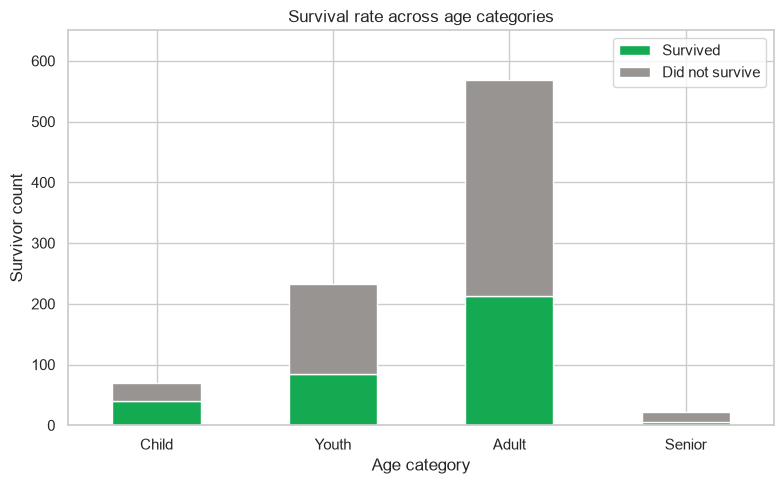

In [9]:
age_summary = dfo.groupby("age_category", observed=False)["survived"].agg(["count", "sum", "mean"]).rename(columns={"count":"total_passengers", 
"mean": "survival_rate", "sum":"survivors"})
age_summary["survival_rate"] = (age_summary["survival_rate"]*100).round(2)
age_summary["non_survivors"] = age_summary["total_passengers"] - age_summary["survivors"]
display(age_summary)

ax = age_summary[["survivors", "non_survivors"]].rename(columns={"non_survivors":"Did not survive", "survivors":"Survived"}).plot(
    kind="bar",
    stacked=True,
    color=["#13aa52", "#989492"],
    figsize=(8,5)
)

ax.set_title("Survival rate across age categories")
ax.set_xlabel("Age category")
plt.xticks(rotation=0)
ax.set_ylabel("Survivor count")
ax.set_ylim(0, 650)
plt.tight_layout()
plt.show()


## Optional SQL/Postgres setup workflow


In [10]:

# from sqlalchemy import create_engine
# engine = None
# engine = create_engine("postgresql://@localhost:5432/f1db")
# dfo.to_sql("titanic_data", engine, if_exists="replace", index=False)
# sql_query = 'SELECT * FROM titanic_data;'
# df = pd.read_sql(sql_query, engine)


## Conclusions

1. Survival was strongly associated with sex: female passengers survived at a much higher rate than male passengers.
2. Survival also followed a clear class gradient, with first-class passengers faring better than second- and third-class passengers.
3. The sex-by-class heatmap suggests that these factors should be considered together rather than treated as isolated predictors.
4. Children had a higher observed survival rate than most older groups, but the age result is affected by median imputation and broad age bands.
5. These are associations in a historical sample, not causal claims. A stronger next step would be a model with a held-out test set and clearly reported evaluation metrics.


## Export and next steps

The cleaned dataset can be exported for Tableau or other tools.

In [12]:
# Optional export for a dashboard workflow.
dfo.to_excel("/Users/samhithkonidena/My Data Journey/Data Job Prep/Portfolio/Analysis/Titanic_Analysis/Cleaned_Data/Titanic_Cleaned_Data.xlsx", index=False)